In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm
from nba import NBAbase, NBAetl, NBAmodels
from dev import NBAdata_
from betting import funcs
odds = funcs.odds()
import pickle
import shap
from nba_api.stats.endpoints import LeagueDashPtStats, PlayerIndex

In [232]:
etl = NBAetl.etl()
data = NBAdata_.data()

In [166]:
p = pi[0][['TEAM_ID','TO_YEAR','PERSON_ID']]

In [233]:
## lets first see a distribution of scorers and league scoring trends throughout the year and has year-over-year

In [234]:
pg = pd.read_sql('select * from pgames',etl.conn)

In [239]:
pg.pts.describe(np.arange(.1,1,.1))

count    206033.000000
mean         10.880839
std           8.572162
min           0.000000
10%           2.000000
20%           3.000000
30%           5.000000
40%           7.000000
50%           9.000000
60%          11.000000
70%          14.000000
80%          18.000000
90%          23.000000
max          73.000000
Name: pts, dtype: float64

In [240]:
for season in pg.season.unique():
    print(season)
    print(pg[pg.season==season].pts.describe(np.arange(.1,1,.1)))

2016-17
count    26017.000000
mean         9.869124
std          8.107636
min          0.000000
10%          0.000000
20%          3.000000
30%          4.000000
40%          6.000000
50%          8.000000
60%         10.000000
70%         13.000000
80%         16.000000
90%         21.000000
max         70.000000
Name: pts, dtype: float64
2017-18
count    21860.000000
mean        10.830238
std          7.953571
min          0.000000
10%          2.000000
20%          4.000000
30%          6.000000
40%          8.000000
50%         10.000000
60%         12.000000
70%         14.000000
80%         17.000000
90%         22.000000
max         60.000000
Name: pts, dtype: float64
2018-19
count    20923.000000
mean        11.315777
std          8.374162
min          0.000000
10%          2.000000
20%          4.000000
30%          6.000000
40%          8.000000
50%         10.000000
60%         12.000000
70%         15.000000
80%         18.000000
90%         23.000000
max         61.000000


- scoring looks fairly consistent year-to-year, we see the mean hover around 11 with the top 10% of players scoring over 23
- this is a right skew for the population, I believe we should see a guassian for the inidivual players though

In [245]:
ptsMean = pg.groupby(['player_id','name']).pts.mean()
ptsCV = pg.groupby(['player_id','name']).pts.std() / pg.groupby(['player_id','name']).pts.mean()

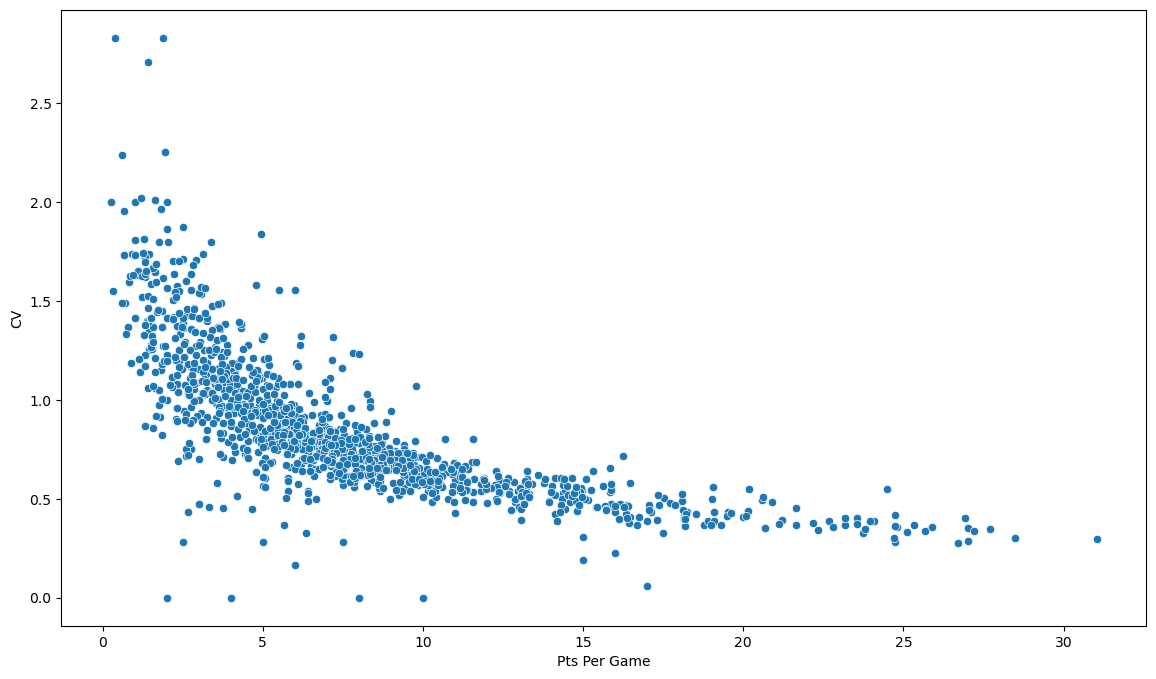

In [251]:
plt.figure(figsize=(14,8))
sns.scatterplot(x=ptsMean,y=ptsCV)
plt.xlabel('Pts Per Game')
plt.ylabel('CV')
plt.show()

- In the above we see that variance shrinks as we get a higher average per game
Lets look at distributions at different quartiles and see what they are like 

,player_id,name,pts
0,101106,Andrew Bogut,2.551724
13,101181,Jose Calderon,4.145455
18,1626148,Anthony Brown,3.909091
21,1626151,Aaron Harrison,4.833333
40,1626173,Rashad Vaughn,3.260870
...,...,...,...
1332,2617,Udonis Haslem,2.370370
1334,2731,Emeka Okafor,4.384615
1340,2746,Josh Smith,2.000000
1344,2760,Anderson Varejao,1.631579


<Axes: ylabel='Count'>

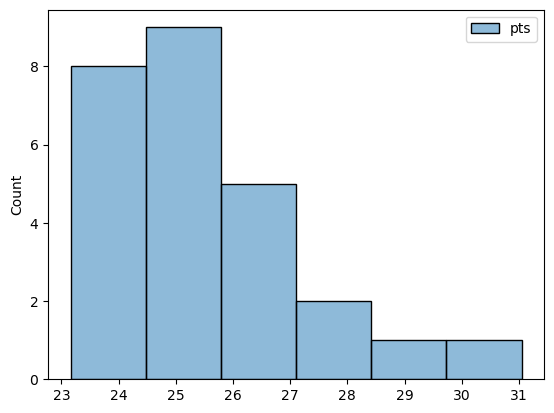

In [319]:
sns.histplot(ptsMean.reset_index()[((ptsMean.reset_index()).pts>=23)])

In [321]:
hs = ptsMean.reset_index()[((ptsMean.reset_index()).pts.between(23,40))].player_id.values

In [323]:
pg[pg.player_id.isin(hs)].groupby('player_id').pts.describe()

,count,mean,std,min,25%,50%,75%,max
player_id,,,,,,,,
1626157,566.0,23.740283,7.817931,2.0,18.00,23.0,28.00,62.0
1626164,591.0,25.903553,9.309327,2.0,19.00,25.0,32.00,70.0
1628368,209.0,25.124402,8.367969,3.0,19.00,25.0,31.00,60.0
1628369,585.0,23.562393,9.431437,0.0,17.00,23.0,30.00,60.0
1628378,532.0,24.798872,8.881038,2.0,19.00,24.0,31.00,71.0
1628983,461.0,24.728850,10.286452,0.0,17.00,25.0,32.00,55.0
1629027,478.0,25.345188,9.299359,2.0,19.00,25.0,31.00,56.0
1629029,253.0,31.047431,9.138144,0.0,25.00,31.0,37.00,73.0
1629627,215.0,24.744186,7.021639,4.0,20.00,25.0,29.00,43.0


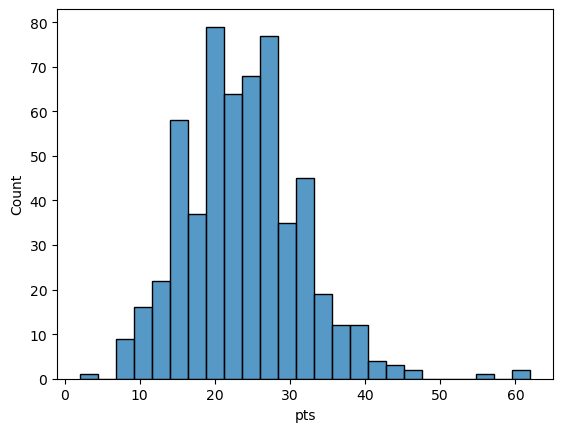

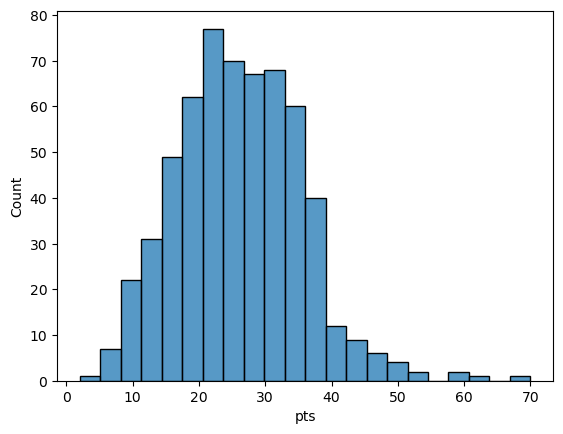

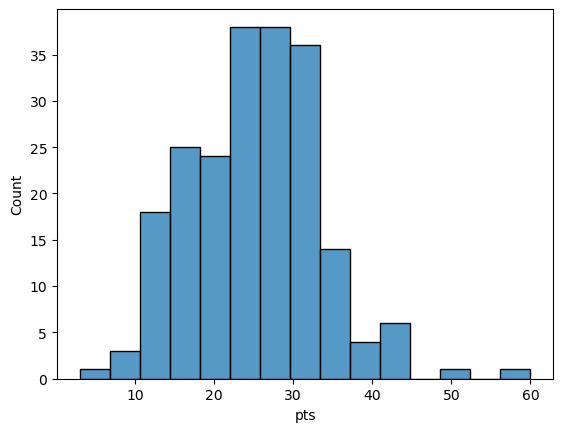

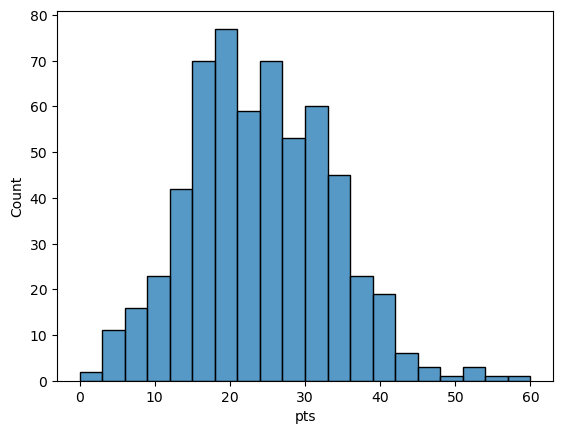

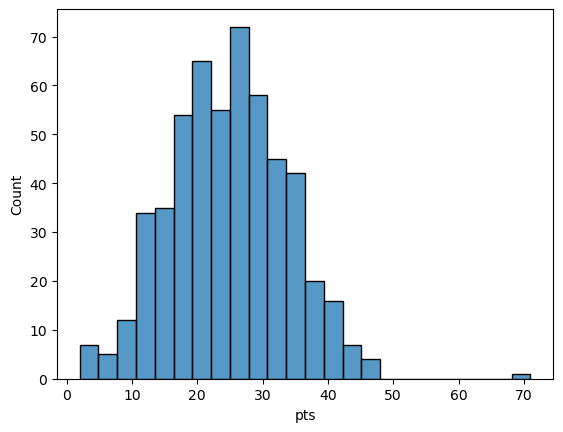

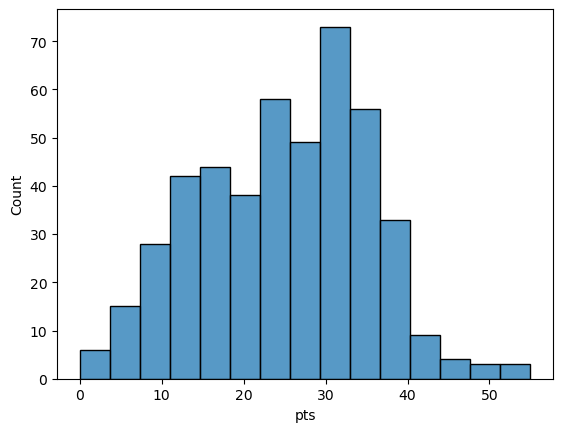

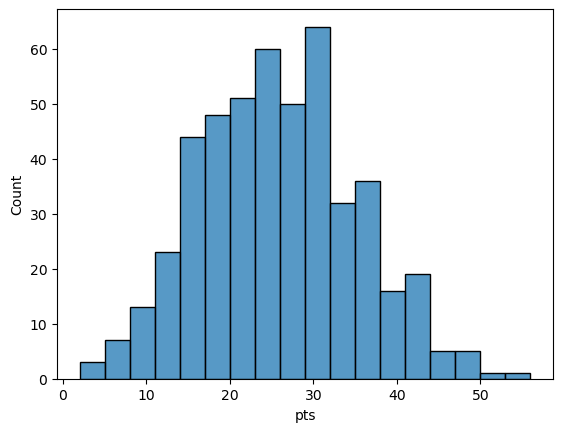

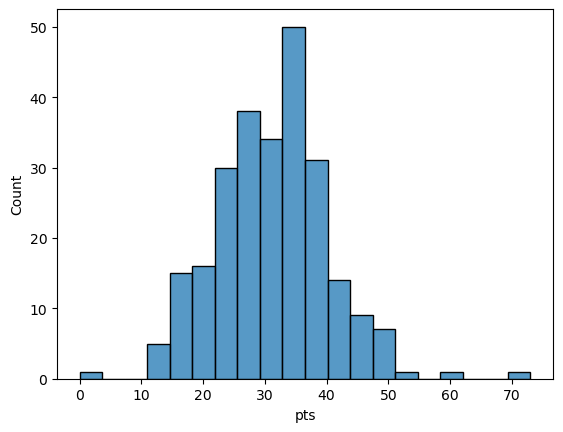

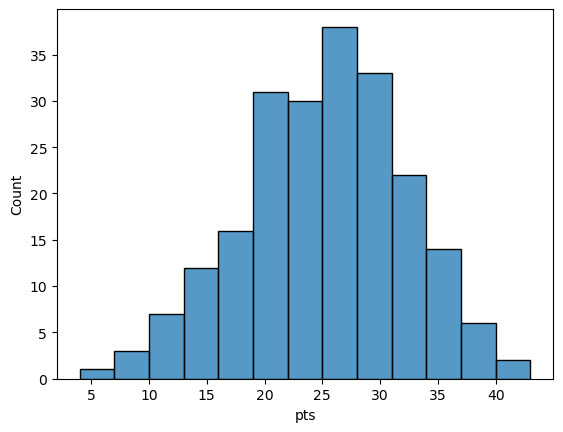

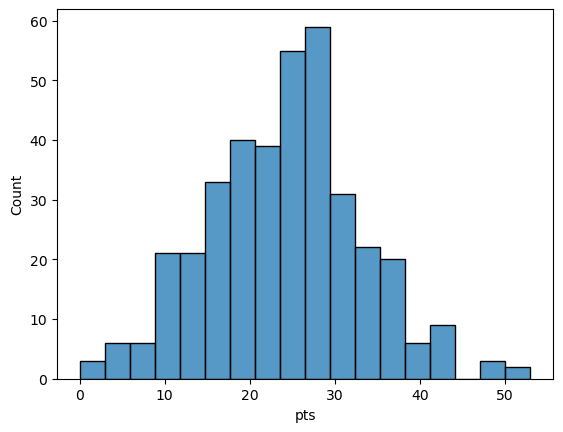

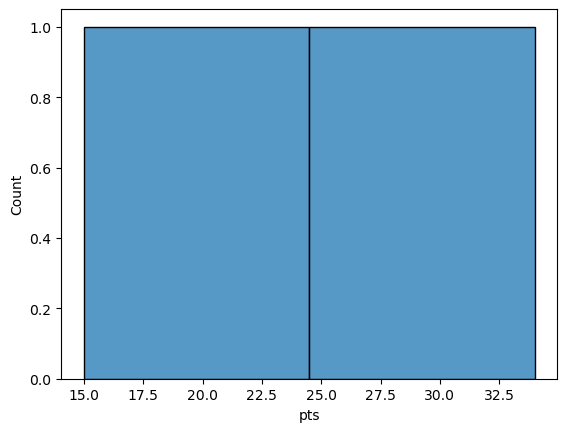

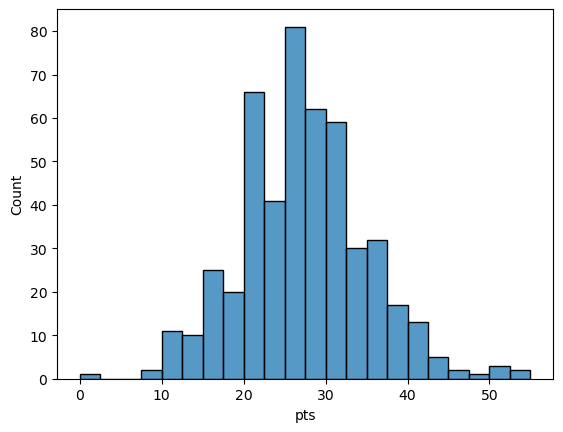

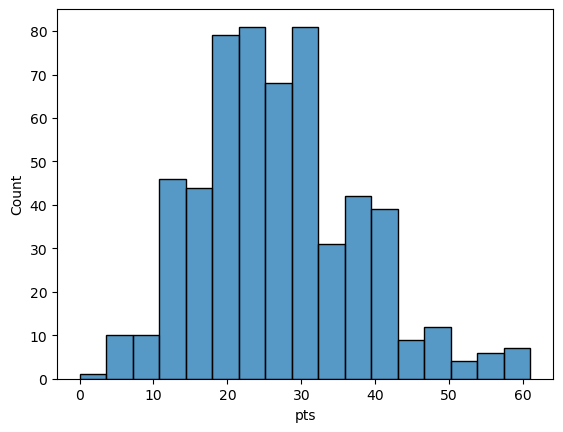

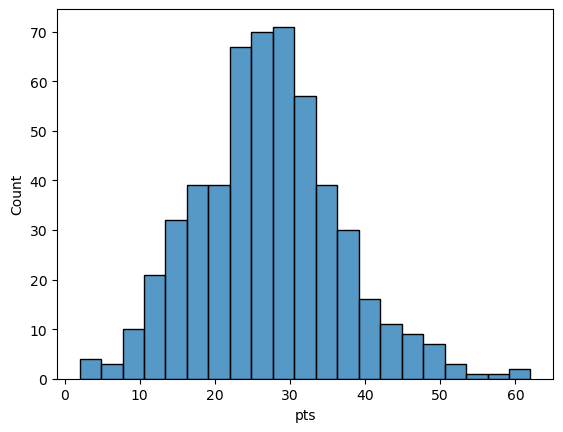

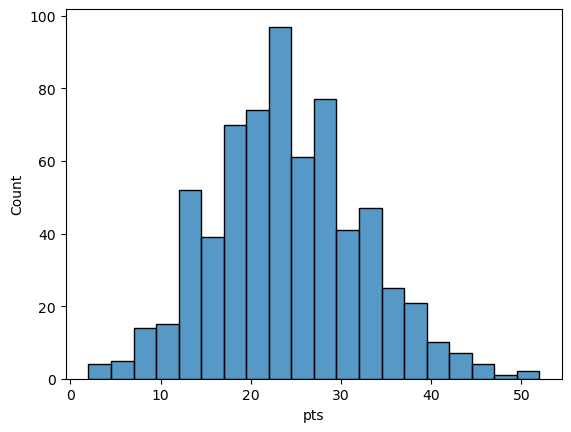

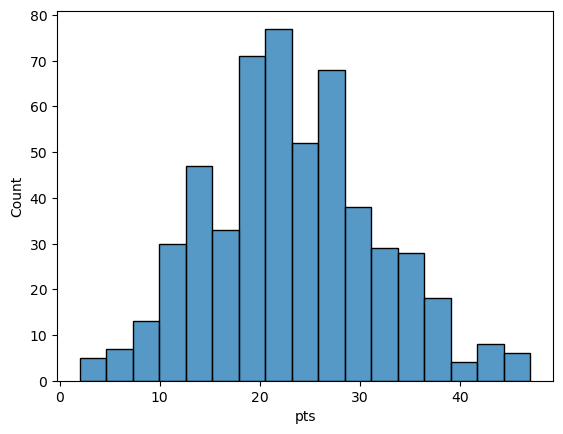

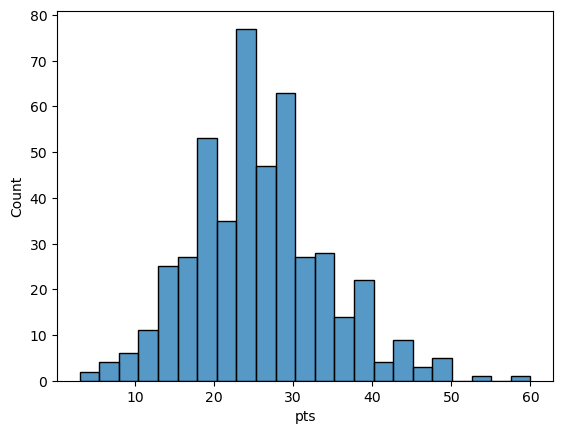

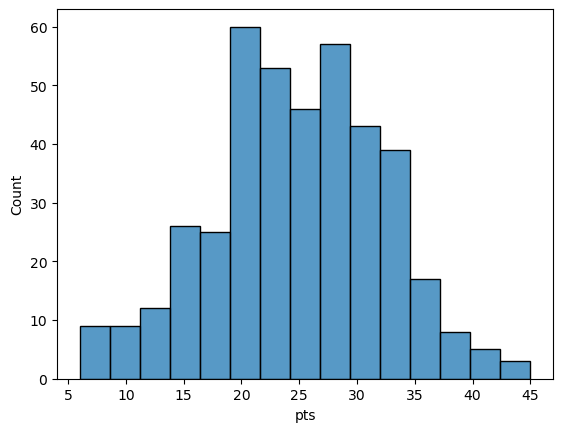

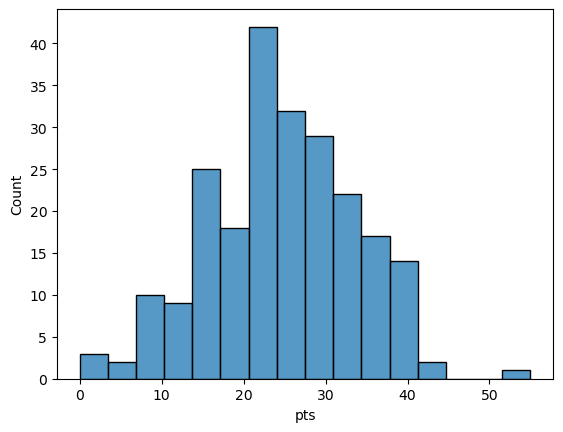

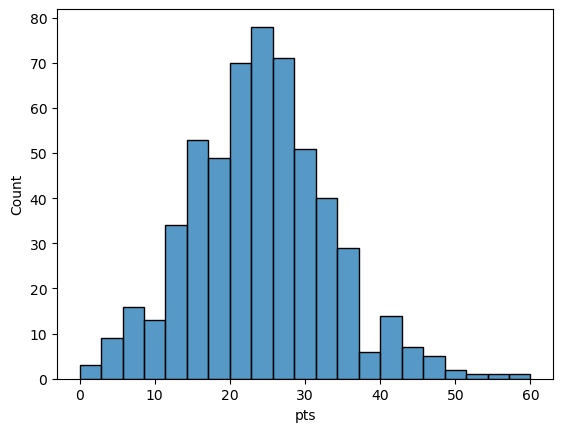

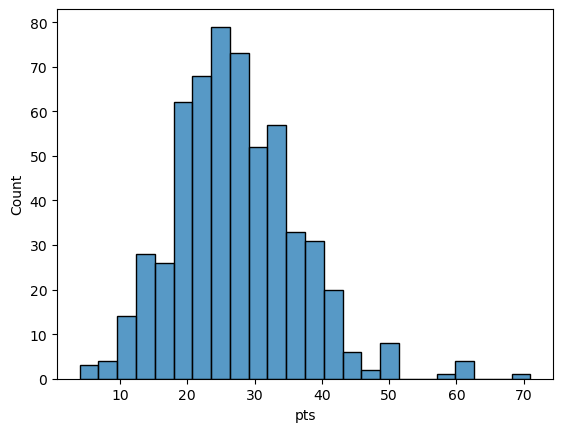

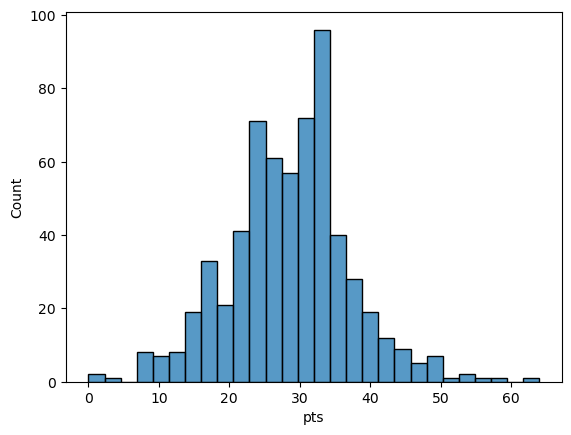

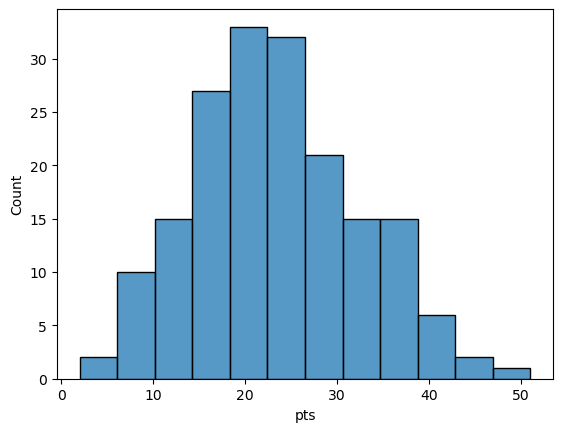

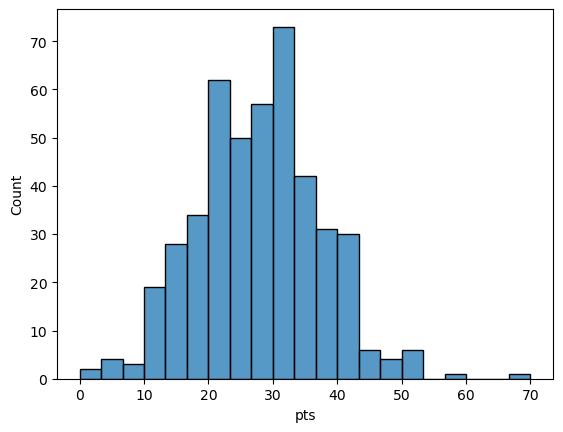

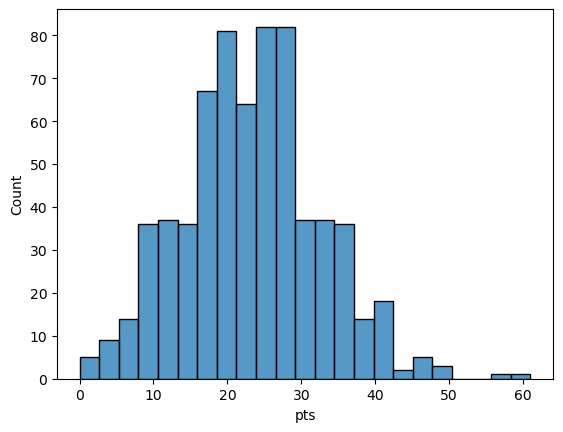

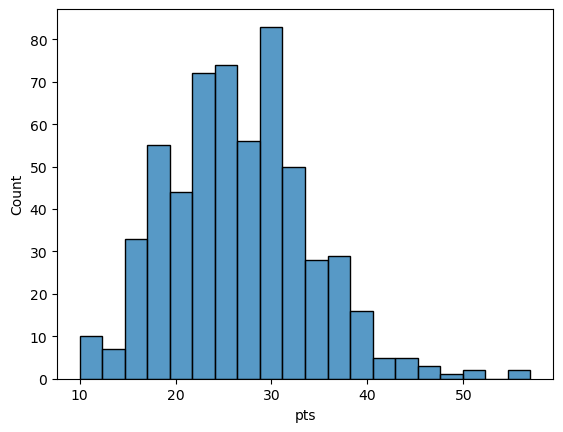

In [322]:
#high scorers
for h in hs:
    temp = pg[pg.player_id==h].pts
    sns.histplot(temp)
    plt.show()